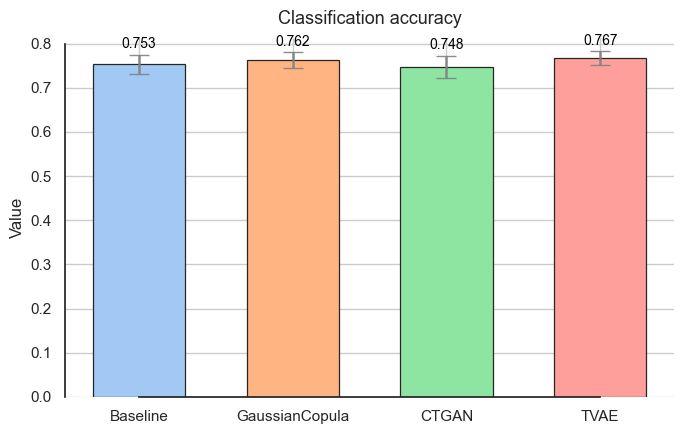

In [16]:
# New cell (index 0) - produces a pretty bar plot with error bars
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data
values = np.array([0.753, 0.762, 0.748, 0.767])
errors = np.array([0.022, 0.018, 0.025, 0.016])
labels = ["Baseline", "GaussianCopula", "CTGAN", "TVAE"]

# Style
sns.set(style="whitegrid", context="notebook", rc={"axes.edgecolor": ".15"})
palette = sns.color_palette("pastel")

# Plot
x = np.arange(len(values))
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    x,
    values,
    yerr=errors,
    color=palette[:len(values)],
    edgecolor="0.15",
    linewidth=0.9,
    width=0.6,
    capsize=7,
    error_kw={"elinewidth": 1.8, "ecolor": "gray", "alpha": 0.9},
)

# Axes & layout
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Value", fontsize=12)
ax.set_title("Classification accuracy", fontsize=13, pad=10)

# Set y-limits with a bit of padding
# ymin = max(0.0, (values - errors).min() - 0.03)
ymin = 0
ymax = (values + errors).max() + 0.03
ax.set_ylim(ymin, ymax)

# Annotate bars with values
for rect, val, err in zip(bars, values, errors):
    height = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        height + err + (ymax - ymin) * 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
    )

sns.despine(trim=True)
plt.tight_layout()
plt.show()

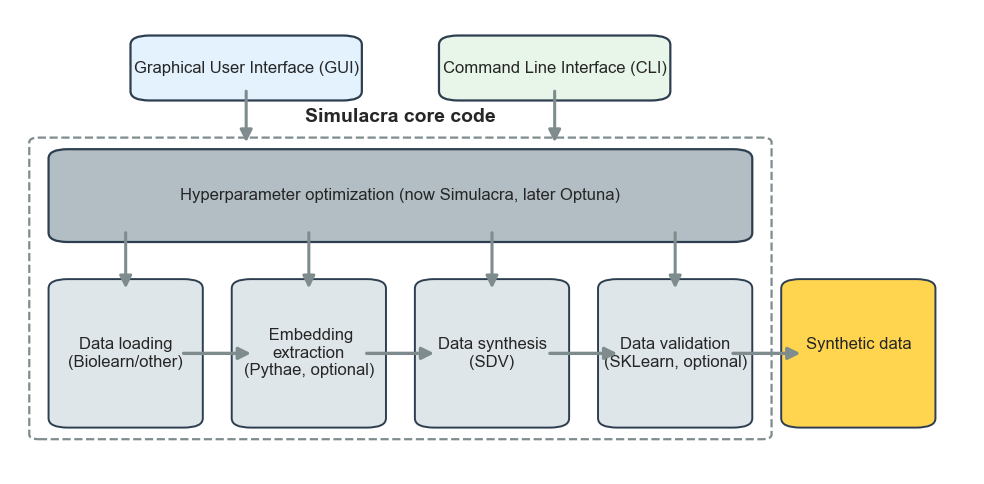

In [15]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

# Unified text size for all labels in this diagram
TEXT_SIZE = 12

# Layout
n = 5
xs = np.linspace(0.12, 0.88, n)
box_w = 0.12
box_h = 0.28
y = 0.12

# Vertical boxes (left -> right)
text = [
    "Data loading\n"
    "(Biolearn/other)",
    " Embedding\nextraction\n"
    "(Pythae, optional)",
    "Data synthesis\n"
    "(SDV)",
    "Data validation\n"
    "(SKLearn, optional)",
    "Synthetic data\n"
]
for i, x in enumerate(xs):
    facecolor = "#FFD54F" if i == n - 1 else "#dfe6e9"
    rect = patches.FancyBboxPatch(
        (x - box_w / 2, y),
        box_w,
        box_h,
        boxstyle="round,pad=0.02",
        linewidth=1.4,
        edgecolor="#2c3e50",
        facecolor=facecolor,
    )
    ax.add_patch(rect)
    ax.text(
        x,
        y + box_h / 2,
        text[i],
        ha="center",
        va="center",
        fontsize=TEXT_SIZE,
    )

# Arrows between vertical boxes (left->right)
for i in range(n - 1):
    x1 = xs[i] + box_w / 2
    x2 = xs[i + 1] - box_w / 2
    y_mid = y + box_h / 2
    ax.annotate(
        "",
        xy=(x2, y_mid),
        xytext=(x1, y_mid),
        arrowprops=dict(arrowstyle="-|>", mutation_scale=18, lw=2.4, color="#7f8c8d", fc="#7f8c8d", shrinkA=0, shrinkB=0),
    )

# Top horizontal box spanning above all but the last (gold) box
top_y = y + box_h + 0.12
top_left = xs[0] - box_w / 2
# stop before the last box so it doesn't float above the golden box
top_right = xs[-2] + box_w / 2
top_width = top_right - top_left
top_height = 0.16
top_rect = patches.FancyBboxPatch(
    (top_left, top_y),
    top_width,
    top_height,
    boxstyle="round,pad=0.02",
    linewidth=1.6,
    edgecolor="#2c3e50",
    facecolor="#b2bec3",
)
ax.add_patch(top_rect)
ax.text(
    top_left + top_width / 2,
    top_y + top_height / 2,
    "Hyperparameter optimization (now Simulacra, later Optuna)",
    ha="center",
    va="center",
    fontsize=TEXT_SIZE,
)

# Dashed bounding rectangle around the core (exclude last gold box)
pad_x = 0.03
pad_y = 0.035
core_left = top_left - pad_x
core_right = top_right + pad_x
core_bottom = y - pad_y
core_top = top_y + top_height + pad_y
core_rect = patches.FancyBboxPatch(
    (core_left, core_bottom),
    core_right - core_left,
    core_top - core_bottom,
    boxstyle="round,pad=0.01",
    linewidth=1.6,
    edgecolor="#7f8c8d",
    facecolor="none",
    linestyle="--",
)
ax.add_patch(core_rect)

# Title above the dashed rectangle
ax.text(
    (core_left + core_right) / 2,
    core_top + 0.035,
    "Simulacra core code",
    ha="center",
    va="bottom",
    fontsize=TEXT_SIZE,
    fontweight="bold",
)

# Arrows from top box down to center of each vertical box
for i, x in enumerate(xs):
    # Skip drawing arrow down to the last (gold) box
    if i == n - 1:
        continue
    ax.annotate(
        "",
        xy=(x, y + box_h),
        xytext=(x, top_y),
        arrowprops=dict(arrowstyle="-|>", mutation_scale=18, lw=2.2, color="#7f8c8d", fc="#7f8c8d", shrinkA=0, shrinkB=0),
    )

# Add GUI and CLI boxes above the core area
upper_y = core_top + 0.11
mid_x = (core_left + core_right) / 2
box_gap = 0.06
ui_box_w = 0.20
ui_box_h = 0.10

# GUI box (left)
left_x = mid_x - box_gap - ui_box_w
gui_rect = patches.FancyBboxPatch(
    (left_x, upper_y),
    ui_box_w,
    ui_box_h,
    boxstyle="round,pad=0.02",
    linewidth=1.6,
    edgecolor="#2c3e50",
    facecolor="#e3f2fd",
)
ax.add_patch(gui_rect)
ax.text(
    left_x + ui_box_w / 2,
    upper_y + ui_box_h / 2,
    "Graphical User Interface (GUI)",
    ha="center",
    va="center",
    fontsize=TEXT_SIZE,
)

# CLI box (right)
right_x = mid_x + box_gap
cli_rect = patches.FancyBboxPatch(
    (right_x, upper_y),
    ui_box_w,
    ui_box_h,
    boxstyle="round,pad=0.02",
    linewidth=1.6,
    edgecolor="#2c3e50",
    facecolor="#e8f5e9",
)
ax.add_patch(cli_rect)
ax.text(
    right_x + ui_box_w / 2,
    upper_y + ui_box_h / 2,
    "Command Line Interface (CLI)",
    ha="center",
    va="center",
    fontsize=TEXT_SIZE,
)

# Arrows from GUI/CLI to core area
ax.annotate(
    "",
    xy=(left_x + ui_box_w / 2, core_top),
    xytext=(left_x + ui_box_w / 2, upper_y),
    arrowprops=dict(arrowstyle="-|>", mutation_scale=18, lw=2.2, color="#7f8c8d", fc="#7f8c8d", shrinkA=0, shrinkB=0),
)
ax.annotate(
    "",
    xy=(right_x + ui_box_w / 2, core_top),
    xytext=(right_x + ui_box_w / 2, upper_y),
    arrowprops=dict(arrowstyle="-|>", mutation_scale=18, lw=2.2, color="#7f8c8d", fc="#7f8c8d", shrinkA=0, shrinkB=0),
)

# Increase title text size above core area
for txt in ax.texts:
    if isinstance(txt.get_text(), str) and txt.get_text() == "Simulacra core code":
        txt.set_fontsize(14)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()